In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

__2 Curve Fit__

In [2]:
df = pd.read_csv('noisy_curvefit_data.csv')

# Shape of data
print(f'Dataframe Shape: {df.shape}')

# Numer of rows and columns
print(f'\nRows: {df.shape[0]} \nColumns: {df.shape[1]}')

# First 5 and last 5 rows
print(f'\nFirst 5 rows: {df.head()}\n\nLast 5 Rows: {df.tail()}')

# Column names
print(f'\nColumn Names: {df.columns}')

Dataframe Shape: (100, 6)

Rows: 100 
Columns: 6

First 5 rows:           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113

Last 5 Rows:            x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850

Column Names: Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')


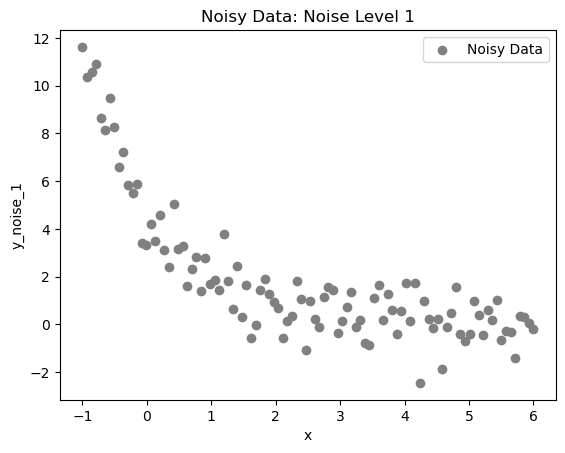

In [3]:
x = df['x']
y_noise_1 = df['y_noise_1']

# Plot
plt.scatter(x, y_noise_1, color='gray', label='Noisy Data')
plt.xlabel('x')
plt.ylabel('y_noise_1')
plt.title('Noisy Data: Noise Level 1')
plt.legend()
plt.show()

Fit: y = 4.71 * e^(-0.92 * x)
Reduced chi-squared: 0.79


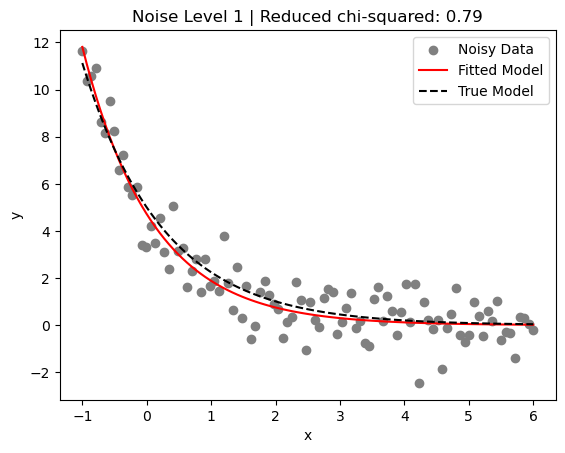

In [4]:
# Define model
def model(x, A, k):
    return A * np.exp(-k * x)

# Fit model to y_noise_1
p0 = [1, 1]  # initial guess
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt

print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

# Calculate reduced chi-squared
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
print(f"Reduced chi-squared: {chi2_reduced:.2f}")

# True model
y_true = model(x, 5, 0.8)

plt.scatter(x, y_noise_1, color='gray', label='Noisy Data')
plt.plot(x, model(x, A_fit, k_fit), color='red', label='Fitted Model')
plt.plot(x, y_true, ls='--', color='black', label='True Model')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Noise Level 1 | Reduced chi-squared: {chi2_reduced:.2f}')
plt.legend()
plt.show()


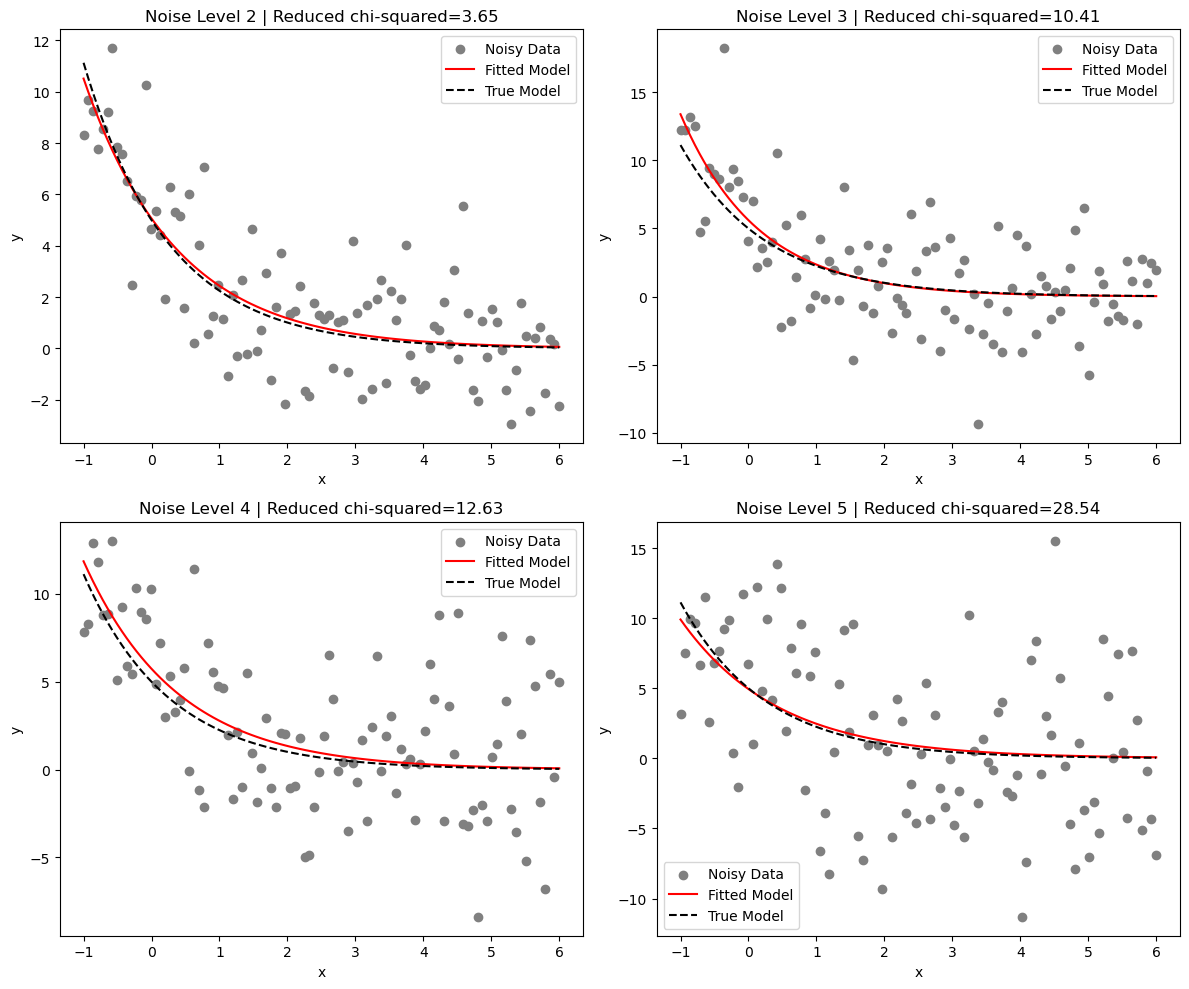

In [5]:
# Define fitting model
def fit_model(x, y):
    popt, _ = curve_fit(model, x, y, p0=[1, 1])
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2_reduced = np.sum(residuals**2) / (len(x) - len(popt))
    return A_fit, k_fit, chi2_reduced

# Noise columns
noise_columns = ['y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']

# Plot
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

results = []

# Loop through for noise lvls 2-5
for i, col in enumerate(noise_columns[1:]):  # skip noise 1 since we already did it
    y = df[col]
    A_fit, k_fit, chi2_red = fit_model(x, y)  # x defined above
    results.append([i+2, A_fit, k_fit, chi2_red])  # Noise level, parameters, chi2

    axs[i].scatter(x, y, color='gray', label='Noisy Data')
    axs[i].plot(x, model(x, A_fit, k_fit), color='red', label='Fitted Model')
    axs[i].plot(x, model(x, 5, 0.8), ls='--', color='black', label='True Model')
    axs[i].set_title(f'Noise Level {i+2} | Reduced chi-squared={chi2_red:.2f}')
    axs[i].set_xlabel('x')
    axs[i].set_ylabel('y')
    axs[i].legend()

plt.tight_layout()
plt.show()

- What happens to the **red and black dotted lines** as you increase the noise level? Why?
    - As we increase the noise level, the red and black dotted line begin to deviate more and more from each other. This is due to the fact that the fitted model is being pulled towards scattered data points as it is trying to perform the fit.
- What happens to the **reduced chi-squared** as you increase the noise level? Why?
    - As we increase the noise level, the reduced chi-squared value becomes larger and larger, futher from 1. This is due to the fact that the greater the scattered data is from the model, the greater the residuals, so the reduced chi-squared also goes up.

In [6]:
# Include Noise Level 1 results
A_fit_1, k_fit_1, chi2_red_1 = fit_model(x, df['y_noise_1'])
results.insert(0, [1, A_fit_1, k_fit_1, chi2_red_1])

# Save to csv
df_results = pd.DataFrame(results, columns=['Noise Level', 'A_fit', 'k_fit', 'Reduced Chi-squared'])
df_results.to_csv('noisy_parameters.csv', index=False)
df_results

,Noise Level,A_fit,k_fit,Reduced Chi-squared
0,1,4.714814,0.918308,0.790673
1,2,5.063889,0.730396,3.649382
2,3,5.609396,0.870372,10.410207
3,4,5.738727,0.725965,12.626832
4,5,4.943458,0.695012,28.538124
